<a href="https://colab.research.google.com/github/Amarah524/Practice/blob/main/Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import random
import os
random.seed(42); np.random.seed(42); tf.random.set_seed(42)
print("TF:", tf.__version__, "| GPU:", len(tf.config.list_physical_devices('GPU')) > 0)

TF: 2.20.0 | GPU: False


In [ ]:
!pip install -q protobuf==5.29.6 tensorflow-metadata==1.17.1 tensorflow_datasets==4.9.7 importlib_resources

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 16.3 MB/s eta 0:00:00


In [ ]:
import numpy as np, pandas as pd, os, re, random, pickle
import warnings; warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Embedding, GRU, Input, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow_datasets as tfds
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
os.makedirs('/content/models', exist_ok=True)
print("Imports done.")

Imports done.


In [ ]:
SELECTED_CLASSES = ['pizza','sushi','hamburger','ice_cream','samosa','ramen','tacos','waffles','fried_rice','chicken_wings']
builder = tfds.builder('food101')
builder.download_and_prepare()
all_class_names = builder.info.features['label'].names
selected_label_ids = [all_class_names.index(c) for c in SELECTED_CLASSES]
train_ds = builder.as_dataset(split='train', as_supervised=True)
val_ds = builder.as_dataset(split='validation', as_supervised=True)
print("Food-101 ready.")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/75750 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.HBRPOI_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...:   0%|          | 0/25250 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.HBRPOI_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.
Food-101 ready.


In [ ]:
import shutil
IMAGE_ROOT = '/content/food_images'
if os.path.exists(IMAGE_ROOT): shutil.rmtree(IMAGE_ROOT)
os.makedirs(IMAGE_ROOT, exist_ok=True)
for cls in SELECTED_CLASSES: os.makedirs(os.path.join(IMAGE_ROOT, cls), exist_ok=True)
old_to_new_label = {old_id: new_id for new_id, old_id in enumerate(selected_label_ids)}

def filter_and_save(dataset, split_name, max_per_class=200):
    records = []; counts = {cls: 0 for cls in SELECTED_CLASSES}
    for image_tensor, label_tensor in dataset:
        label_id = int(label_tensor.numpy())
        if label_id not in old_to_new_label: continue
        class_name = all_class_names[label_id]
        if counts[class_name] >= max_per_class: continue
        img = Image.fromarray(image_tensor.numpy())
        filename = f"{split_name}_{class_name}_{counts[class_name]:04d}.jpg"
        filepath = os.path.join(IMAGE_ROOT, class_name, filename)
        img.save(filepath, format='JPEG')
        records.append({'image_path': filepath, 'dish_label': class_name,
                         'dish_label_id': old_to_new_label[label_id]})
        counts[class_name] += 1
        if all(c >= max_per_class for c in counts.values()): break
    return records

train_records = filter_and_save(train_ds, 'train', 200)
val_records = filter_and_save(val_ds, 'val', 50)
print("Images saved:", len(train_records) + len(val_records))

Images saved: 2500


In [ ]:
image_df = pd.DataFrame(train_records + val_records)
train_val_df, test_df = train_test_split(image_df, test_size=0.15, stratify=image_df['dish_label'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.176, stratify=train_val_df['dish_label'], random_state=42)
assert len(set(train_df['image_path']) & set(val_df['image_path'])) == 0
assert len(set(train_df['image_path']) & set(test_df['image_path'])) == 0
assert len(set(val_df['image_path']) & set(test_df['image_path'])) == 0
print(f"Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)} -- no leakage")

Train 1751 | Val 374 | Test 375 -- no leakage


Class distribution:
dish_label
pizza            250
waffles          250
hamburger        250
tacos            250
fried_rice       250
samosa           250
ice_cream        250
ramen            250
sushi            250
chicken_wings    250
Name: count, dtype: int64

Missing files: 0 out of 2500


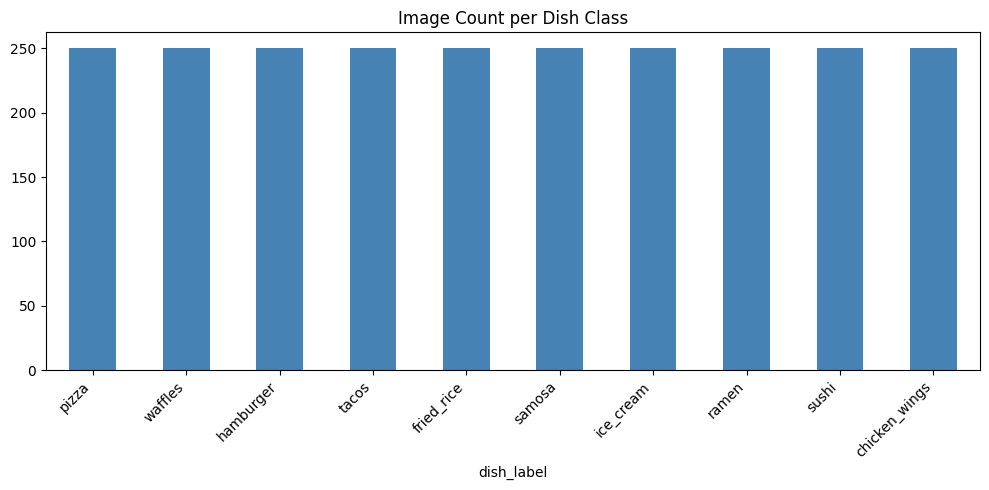

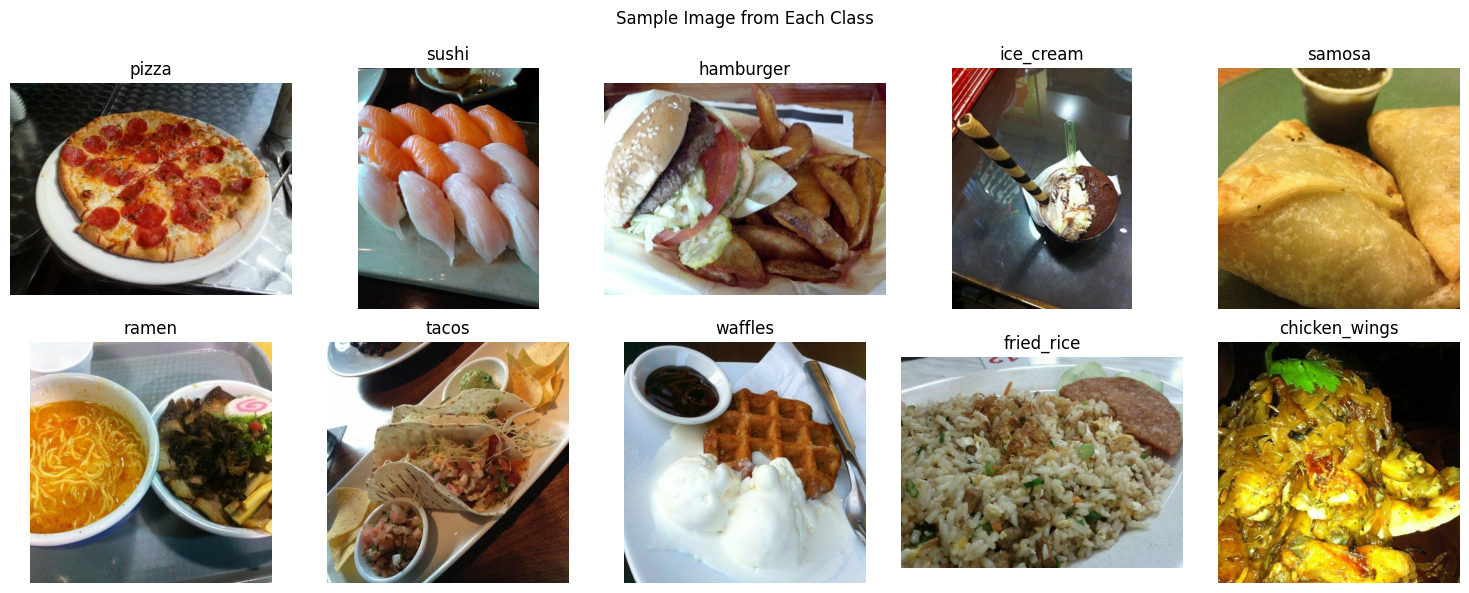

In [ ]:
print("Class distribution:")
print(image_df['dish_label'].value_counts())

missing = [p for p in image_df['image_path'] if not os.path.exists(p)]
print(f"\nMissing files: {len(missing)} out of {len(image_df)}")

plt.figure(figsize=(10,5))
image_df['dish_label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Image Count per Dish Class'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.flatten()
for i, cls in enumerate(SELECTED_CLASSES):
    sample_path = image_df[image_df['dish_label']==cls]['image_path'].iloc[0]
    axes[i].imshow(plt.imread(sample_path)); axes[i].set_title(cls); axes[i].axis('off')
plt.suptitle('Sample Image from Each Class'); plt.tight_layout(); plt.show()

In [ ]:
IMG_SIZE = 160; BATCH_SIZE = 32; NUM_CLASSES = len(SELECTED_CLASSES)

def load_and_preprocess_image(path, label, augment=False):
    image = tf.io.read_file(path); image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    if augment:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.1)
        image = tf.image.random_contrast(image, 0.9, 1.1)
    return mobilenet_preprocess(image), label

def make_dataset(df, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df['image_path'].values, df['dish_label_id'].values))
    if shuffle: ds = ds.shuffle(len(df), seed=42)
    ds = ds.map(lambda p, l: load_and_preprocess_image(p, l, augment), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset_img = make_dataset(train_df, augment=True, shuffle=True)
val_dataset_img = make_dataset(val_df)
test_dataset_img = make_dataset(test_df)
print("Image pipeline ready.")

Image pipeline ready.


In [ ]:
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D(name='image_embedding')(x)
x = Dense(256, activation='relu')(x); x = BatchNormalization()(x); x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
cnn_model = Model(inputs, outputs)
cnn_model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

CNN_MODEL_PATH = '/content/models/best_cnn_model.keras'
cb = [EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
      ModelCheckpoint(CNN_MODEL_PATH, monitor='val_accuracy', save_best_only=True),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)]
history_cnn = cnn_model.fit(train_dataset_img, validation_data=val_dataset_img, epochs=25, callbacks=cb)
print("Best val_accuracy:", max(history_cnn.history['val_accuracy']))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 535ms/step - accuracy: 0.6533 - loss: 1.1504 - val_accuracy: 0.7834 - val_loss: 0.7308 - learning_rate: 0.0010
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 504ms/step - accuracy: 0.8612 - loss: 0.4327 - val_accuracy: 0.8316 - val_loss: 0.5869 - learning_rate: 0.0010
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 43s 537ms/step - accuracy: 0.8949 - loss: 0.3228 - val_accuracy: 0.8262 - val_loss: 0.5634 - learning_rate: 0.0010
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 38s 482ms/step - accuracy: 0.9383 - loss: 0.2006 - val_accuracy: 0.8075 - val_loss: 0.6115 - learning_rate: 0.0010
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 26s 477ms/step - accuracy: 0.9537 - loss: 0.1627 - val_accuracy: 0.8182 - val_loss: 0.6258 - learning_rate: 0.0010
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 47s 597ms/step - accuracy: 0.9674 - loss: 0.1193 - val_accuracy: 0.8128 - val_loss: 0.6376 - learning_rate: 0.0010
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━

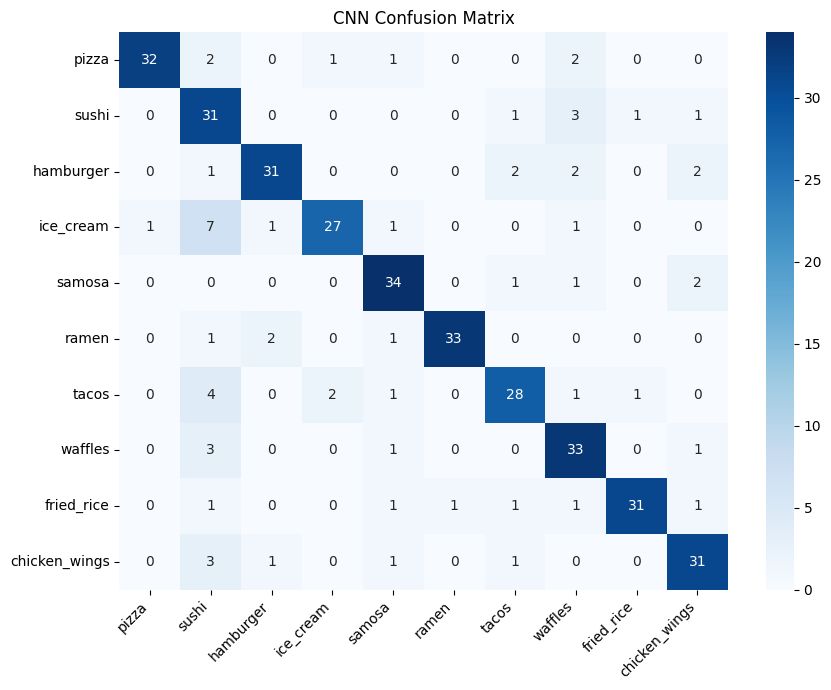

               precision    recall  f1-score   support

        pizza       0.97      0.84      0.90        38
        sushi       0.58      0.84      0.69        37
    hamburger       0.89      0.82      0.85        38
    ice_cream       0.90      0.71      0.79        38
       samosa       0.83      0.89      0.86        38
        ramen       0.97      0.89      0.93        37
        tacos       0.82      0.76      0.79        37
      waffles       0.75      0.87      0.80        38
   fried_rice       0.94      0.84      0.89        37
chicken_wings       0.82      0.84      0.83        37

     accuracy                           0.83       375
    macro avg       0.85      0.83      0.83       375
 weighted avg       0.85      0.83      0.83       375



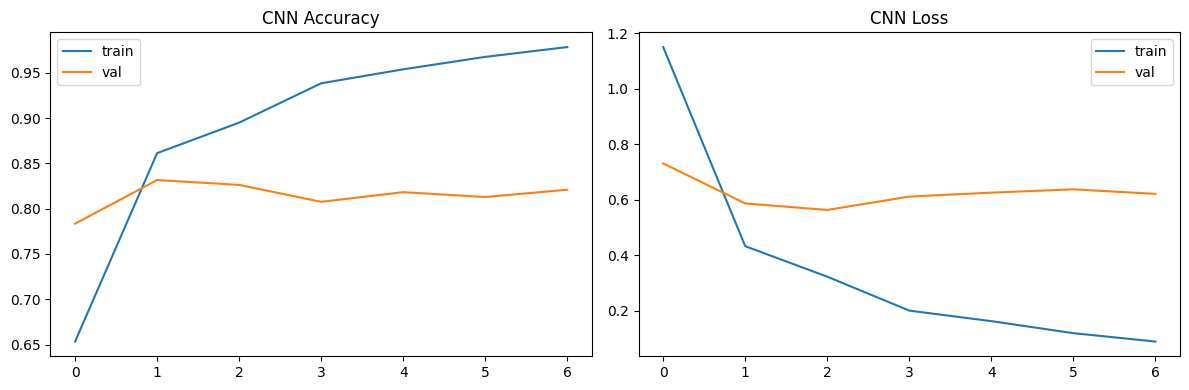

In [ ]:
best_cnn_model = load_model(CNN_MODEL_PATH)
y_true, y_pred = [], []
for images, labels in test_dataset_img:
    preds = best_cnn_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1)); y_true.extend(labels.numpy())
y_true, y_pred = np.array(y_true), np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7)); sns.heatmap(cm, annot=True, fmt='d', xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES, cmap='Blues')
plt.title('CNN Confusion Matrix'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
print(classification_report(y_true, y_pred, target_names=SELECTED_CLASSES))

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(history_cnn.history['accuracy'], label='train'); axes[0].plot(history_cnn.history['val_accuracy'], label='val')
axes[0].set_title('CNN Accuracy'); axes[0].legend()
axes[1].plot(history_cnn.history['loss'], label='train'); axes[1].plot(history_cnn.history['val_loss'], label='val')
axes[1].set_title('CNN Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
image_embedding_model = Model(inputs=best_cnn_model.input, outputs=best_cnn_model.get_layer('image_embedding').output)

def extract_image_embedding(image_path):
    image = tf.io.read_file(image_path); image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = mobilenet_preprocess(image); image = tf.expand_dims(image, 0)
    return image_embedding_model.predict(image, verbose=0)[0]

print("Image embedding extractor ready. Shape test:", extract_image_embedding(test_df['image_path'].iloc[0]).shape)

Image embedding extractor ready. Shape test: (1280,)


In [ ]:
!pip install -q datasets
from datasets import load_dataset
review_dataset = load_dataset("fancyzhx/amazon_polarity")
print("Reviews loaded:", review_dataset)

README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

amazon_polarity/train-00000-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  260MB            

amazon_polarity/train-00000-of-00004.par(…): downloading bytes:           |  0.00B            

amazon_polarity/train-00001-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  258MB            

amazon_polarity/train-00001-of-00004.par(…): downloading bytes:           |  0.00B            

...

amazon_polarity/test-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B /  117MB            

amazon_polarity/test-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Reviews loaded: DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})


In [ ]:
shuffled = review_dataset['train'].shuffle(seed=42)
pos = shuffled.filter(lambda x: x['label']==1).select(range(10000)).to_pandas()
neg = shuffled.filter(lambda x: x['label']==0).select(range(10000)).to_pandas()
review_df = pd.concat([pos, neg], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
review_df = review_df.rename(columns={'content':'review_text','label':'sentiment'})[['review_text','sentiment']]
print("Reviews prepared:", len(review_df))

Filter:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Reviews prepared: 20000


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

review_df['cleaned_text'] = review_df['review_text'].apply(clean_text)
text_train_val_df, text_test_df = train_test_split(review_df, test_size=0.15, stratify=review_df['sentiment'], random_state=42)
text_train_df, text_val_df = train_test_split(text_train_val_df, test_size=0.176, stratify=text_train_val_df['sentiment'], random_state=42)

VOCAB_SIZE = 10000; MAX_SEQUENCE_LENGTH = 100
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(text_train_df['cleaned_text'])

def texts_to_padded_sequences(texts, tok, max_len):
    return pad_sequences(tok.texts_to_sequences(texts), maxlen=max_len, padding='post', truncating='post')

X_train_text = texts_to_padded_sequences(text_train_df['cleaned_text'], tokenizer, MAX_SEQUENCE_LENGTH)
X_val_text = texts_to_padded_sequences(text_val_df['cleaned_text'], tokenizer, MAX_SEQUENCE_LENGTH)
X_test_text = texts_to_padded_sequences(text_test_df['cleaned_text'], tokenizer, MAX_SEQUENCE_LENGTH)
y_train_text = text_train_df['sentiment'].values
y_val_text = text_val_df['sentiment'].values
y_test_text = text_test_df['sentiment'].values

with open('/content/models/tokenizer.pkl','wb') as f: pickle.dump(tokenizer, f)
print("Text preprocessing done. Train shape:", X_train_text.shape)

Text preprocessing done. Train shape: (14008, 100)


In [ ]:
inputs = Input(shape=(MAX_SEQUENCE_LENGTH,))
x = Embedding(VOCAB_SIZE, 128)(inputs)
x = GRU(64, dropout=0.3)(x)
x = Dense(64, activation='relu', name='text_embedding')(x)
x = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid')(x)
gru_model = Model(inputs, outputs)
gru_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

GRU_MODEL_PATH = '/content/models/best_gru_model.keras'
cb = [EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
      ModelCheckpoint(GRU_MODEL_PATH, monitor='val_accuracy', save_best_only=True),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)]
history_gru = gru_model.fit(X_train_text, y_train_text, validation_data=(X_val_text, y_val_text),
                             epochs=20, batch_size=64, callbacks=cb)
print("Best val_accuracy:", max(history_gru.history['val_accuracy']))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 47s 191ms/step - accuracy: 0.5126 - loss: 0.6925 - val_accuracy: 0.5164 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.5515 - loss: 0.6749 - val_accuracy: 0.5468 - val_loss: 0.6848 - learning_rate: 0.0010
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.7501 - loss: 0.4894 - val_accuracy: 0.8222 - val_loss: 0.4003 - learning_rate: 0.0010
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - accuracy: 0.8986 - loss: 0.2608 - val_accuracy: 0.8332 - val_loss: 0.3983 - learning_rate: 0.0010
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.9378 - loss: 0.1724 - val_accuracy: 0.8255 - val_loss: 0.5071 - learning_rate: 0.0010
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9629 - loss: 0.1101 - val_accuracy: 0.8262 - val_loss: 0.6004 - learning_rate: 0.0010
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 141ms/step - accuracy: 0.9772 

In [ ]:
best_gru_model = load_model(GRU_MODEL_PATH)
y_pred_probs = best_gru_model.predict(X_test_text, verbose=0)
y_pred_gru = (y_pred_probs >= 0.5).astype(int).flatten()
print(classification_report(y_test_text, y_pred_gru, target_names=['Negative','Positive']))

text_embedding_model = Model(inputs=best_gru_model.input, outputs=best_gru_model.get_layer('text_embedding').output)

def extract_text_embedding(review_text):
    seq = texts_to_padded_sequences([clean_text(review_text)], tokenizer, MAX_SEQUENCE_LENGTH)
    return text_embedding_model.predict(seq, verbose=0)[0]

print("Text embedding ready.")

              precision    recall  f1-score   support

    Negative       0.81      0.86      0.84      1500
    Positive       0.86      0.80      0.83      1500

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000

Text embedding ready.


In [ ]:
random.seed(42)
DISH_ASPECTS = {'pizza':['cheese','crust','toppings','sauce'],'sushi':['rice','fish','wasabi','freshness'],
    'hamburger':['patty','bun','toppings','juiciness'],'ice_cream':['flavor','texture','sweetness','creaminess'],
    'samosa':['filling','crust','spice level','crispiness'],'ramen':['broth','noodles','toppings','seasoning'],
    'tacos':['filling','tortilla','salsa','seasoning'],'waffles':['texture','syrup','crispiness','fluffiness'],
    'fried_rice':['seasoning','vegetables','texture','flavor'],'chicken_wings':['sauce','crispiness','spice level','meat']}
POS_ADJ = ['delicious','amazing','fantastic','excellent','wonderful','flavorful','perfect','outstanding','incredible','superb']
NEG_ADJ = ['bland','disappointing','terrible','awful','stale','overcooked','undercooked','tasteless','soggy','dry']
NEU_ADJ = ['okay','decent','average','acceptable','fine']
NEUTRAL_TEMPLATES = ["The {dish} was {adj1} and the {aspect} was {adj2}.", "The {aspect} of the {dish} was {adj1}.",
    "The {dish} arrived {adj1}, and the {aspect} was {adj2}.", "This {dish} had {adj1} {aspect}."]
POS_TEMPLATES = ["I really enjoyed the {dish}, especially the {aspect}.", "This {dish} had {adj1} {aspect}, would recommend.",
    "Great {dish}! The {aspect} was {adj1} and {adj2}."]
NEG_TEMPLATES = ["Not a fan of this {dish} -- the {aspect} was {adj1}.", "Would not order this {dish} again -- the {aspect} was {adj1}.",
    "Disappointed with the {dish}; the {aspect} was {adj1} and {adj2}."]

def generate_review(dish_name, sentiment):
    aspect = random.choice(DISH_ASPECTS[dish_name])
    if sentiment == 'positive':
        a1, a2 = random.sample(POS_ADJ, 2); rating = round(random.uniform(4.0,5.0),1)
        template = random.choice(NEUTRAL_TEMPLATES + POS_TEMPLATES)
    elif sentiment == 'negative':
        a1, a2 = random.sample(NEG_ADJ, 2); rating = round(random.uniform(1.0,2.5),1)
        template = random.choice(NEUTRAL_TEMPLATES + NEG_TEMPLATES)
    else:
        a1, a2 = random.sample(NEU_ADJ, 2); rating = round(random.uniform(2.5,4.0),1)
        template = random.choice(NEUTRAL_TEMPLATES)
    text = template.format(dish=dish_name.replace('_',' '), aspect=aspect, adj1=a1, adj2=a2)
    return text, rating

print(generate_review('pizza','positive'))
print(generate_review('ramen','negative'))

('The cheese of the pizza was delicious.', 4.2)
('The ramen was soggy and the broth was disappointing.', 1.9)


In [ ]:
def build_multimodal_dataset(image_df, split_name):
    records = []
    dishes = list(DISH_ASPECTS.keys())
    for _, row in image_df.iterrows():
        correct_dish = row['dish_label']; image_path = row['image_path']
        s = random.choice(['positive','negative','neutral'])
        text, rating = generate_review(correct_dish, s)
        records.append({'image_path': image_path, 'review_text': text, 'dish_label': correct_dish,
                         'rating': rating, 'sentiment': 1 if s=='positive' else 0, 'match_label': 1})
        wrong_dish = random.choice([d for d in dishes if d != correct_dish])
        s2 = random.choice(['positive','negative','neutral'])
        text2, rating2 = generate_review(wrong_dish, s2)
        records.append({'image_path': image_path, 'review_text': text2, 'dish_label': correct_dish,
                         'rating': rating2, 'sentiment': 1 if s2=='positive' else 0, 'match_label': 0})
    return pd.DataFrame(records)

multimodal_train_df = build_multimodal_dataset(train_df, 'train')
multimodal_val_df = build_multimodal_dataset(val_df, 'val')
multimodal_test_df = build_multimodal_dataset(test_df, 'test')
print("Sizes:", len(multimodal_train_df), len(multimodal_val_df), len(multimodal_test_df))
print(multimodal_train_df['match_label'].value_counts())

Sizes: 3502 748 750
match_label
1    1751
0    1751
Name: count, dtype: int64


In [ ]:
def extract_dish_keyword_vector(review_text):
    """
    Simple, deterministic, zero-training feature: a 10-dim vector where
    position i = 1 if dish i's name appears (as a word) in the review text.
    This directly gives the fusion model reliable dish-identity signal,
    without depending on a separately trained embedding.
    """
    cleaned = clean_text(review_text)
    words = set(cleaned.split())
    vec = np.zeros(len(SELECTED_CLASSES))
    for i, dish in enumerate(SELECTED_CLASSES):
        dish_words = dish.split('_')  # e.g. 'ice_cream' -> ['ice','cream']
        if all(w in words for w in dish_words):
            vec[i] = 1.0
    return vec

# quick test
print("pizza review ->", extract_dish_keyword_vector("The pizza was delicious and the cheese was great."))
print("ramen review ->", extract_dish_keyword_vector("The ramen broth was awful."))

pizza review -> [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
ramen review -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
from tqdm import tqdm

def extract_fused_features(df):
    img_embs, txt_embs, kw_vecs = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_embs.append(extract_image_embedding(row['image_path']))
        txt_embs.append(extract_text_embedding(row['review_text']))
        kw_vecs.append(extract_dish_keyword_vector(row['review_text']))
    return np.array(img_embs), np.array(txt_embs), np.array(kw_vecs), df['match_label'].values

print("Extracting TRAIN..."); X_train_img, X_train_txt, X_train_kw, y_train_match = extract_fused_features(multimodal_train_df)
print("Extracting VAL...");   X_val_img, X_val_txt, X_val_kw, y_val_match = extract_fused_features(multimodal_val_df)
print("Extracting TEST...");  X_test_img, X_test_txt, X_test_kw, y_test_match = extract_fused_features(multimodal_test_df)

X_train_fused = np.concatenate([X_train_img, X_train_txt, X_train_kw], axis=1)
X_val_fused = np.concatenate([X_val_img, X_val_txt, X_val_kw], axis=1)
X_test_fused = np.concatenate([X_test_img, X_test_txt, X_test_kw], axis=1)
print("Fused shapes:", X_train_fused.shape, X_val_fused.shape, X_test_fused.shape)

np.save('/content/models/X_train_fused.npy', X_train_fused); np.save('/content/models/y_train_match.npy', y_train_match)
np.save('/content/models/X_val_fused.npy', X_val_fused); np.save('/content/models/y_val_match.npy', y_val_match)
np.save('/content/models/X_test_fused.npy', X_test_fused); np.save('/content/models/y_test_match.npy', y_test_match)

Extracting TRAIN...


100%|██████████| 3502/3502 [10:03<00:00,  5.81it/s]


Extracting VAL...


100%|██████████| 748/748 [02:16<00:00,  5.47it/s]


Extracting TEST...


100%|██████████| 750/750 [02:06<00:00,  5.91it/s]


Fused shapes: (3502, 1354) (748, 1354) (750, 1354)


In [ ]:
#ADD CNN CLASS-PROBABILITY FEATURE (fixes weak signal)


def extract_image_class_probs(image_path):
    """Returns the CNN's actual 10-way softmax prediction for this image."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = mobilenet_preprocess(image)
    image = tf.expand_dims(image, 0)
    return best_cnn_model.predict(image, verbose=0)[0]  # shape (10,)

from tqdm import tqdm

def extract_fused_features_v2(df):
    img_embs, img_probs, txt_embs, kw_vecs = [], [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_embs.append(extract_image_embedding(row['image_path']))
        img_probs.append(extract_image_class_probs(row['image_path']))
        txt_embs.append(extract_text_embedding(row['review_text']))
        kw_vecs.append(extract_dish_keyword_vector(row['review_text']))
    return (np.array(img_embs), np.array(img_probs), np.array(txt_embs),
            np.array(kw_vecs), df['match_label'].values)

print("Extracting TRAIN...")
X_train_img, X_train_probs, X_train_txt, X_train_kw, y_train_match = extract_fused_features_v2(multimodal_train_df)
print("Extracting VAL...")
X_val_img, X_val_probs, X_val_txt, X_val_kw, y_val_match = extract_fused_features_v2(multimodal_val_df)
print("Extracting TEST...")
X_test_img, X_test_probs, X_test_txt, X_test_kw, y_test_match = extract_fused_features_v2(multimodal_test_df)

# New fused vector: image embedding + CNN class-probs + text embedding + keyword vector
X_train_fused = np.concatenate([X_train_img, X_train_probs, X_train_txt, X_train_kw], axis=1)
X_val_fused = np.concatenate([X_val_img, X_val_probs, X_val_txt, X_val_kw], axis=1)
X_test_fused = np.concatenate([X_test_img, X_test_probs, X_test_txt, X_test_kw], axis=1)

print("New fused shapes:", X_train_fused.shape, X_val_fused.shape, X_test_fused.shape)

np.save('/content/models/X_train_fused.npy', X_train_fused)
np.save('/content/models/X_val_fused.npy', X_val_fused)
np.save('/content/models/X_test_fused.npy', X_test_fused)
np.save('/content/models/y_train_match.npy', y_train_match)
np.save('/content/models/y_val_match.npy', y_val_match)
np.save('/content/models/y_test_match.npy', y_test_match)

# Quick sanity check: does the class-prob argmax vs keyword argmax correlate with match_label?
pred_dish = np.argmax(X_train_probs, axis=1)
mentioned_dish = np.argmax(X_train_kw, axis=1)
agrees = (pred_dish == mentioned_dish).astype(int)
agreement_accuracy = (agrees == y_train_match).mean()
print(f"\nSimple alignment-check accuracy (no model needed): {agreement_accuracy:.4f}")
print("(This tells us the theoretical ceiling this feature alone should let the model reach)")

Extracting TRAIN...


100%|██████████| 3502/3502 [16:43<00:00,  3.49it/s]


Extracting VAL...


100%|██████████| 748/748 [03:35<00:00,  3.46it/s]


Extracting TEST...


100%|██████████| 750/750 [03:17<00:00,  3.81it/s]

New fused shapes: (3502, 1364) (748, 1364) (750, 1364)

Simple alignment-check accuracy (no model needed): 0.9654
(This tells us the theoretical ceiling this feature alone should let the model reach)


In [ ]:


FUSED_DIM = X_train_fused.shape[1]

inputs = Input(shape=(FUSED_DIM,))
x = BatchNormalization()(inputs)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu', name='fused_representation')(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)
fusion_model = Model(inputs, outputs)
fusion_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

FUSION_MODEL_PATH = '/content/models/best_fusion_model.keras'
cb = [EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
      ModelCheckpoint(FUSION_MODEL_PATH, monitor='val_accuracy', save_best_only=True),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)]

history_fusion = fusion_model.fit(X_train_fused, y_train_match, validation_data=(X_val_fused, y_val_match),
                                   epochs=40, batch_size=32, callbacks=cb)
print("Best val_accuracy:", max(history_fusion.history['val_accuracy']))

Epoch 1/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4680 - loss: 0.9197 - val_accuracy: 0.5040 - val_loss: 0.7019 - learning_rate: 0.0010
Epoch 2/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4966 - loss: 0.7898 - val_accuracy: 0.5374 - val_loss: 0.6994 - learning_rate: 0.0010
Epoch 3/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5117 - loss: 0.7547 - val_accuracy: 0.5428 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 4/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5220 - loss: 0.7354 - val_accuracy: 0.5374 - val_loss: 0.6873 - learning_rate: 0.0010
Epoch 5/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5334 - loss: 0.7082 - val_accuracy: 0.5495 - val_loss: 0.6818 - learning_rate: 0.0010
Epoch 6/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5583 - loss: 0.6906 - val_accuracy: 0.6056 - val_loss: 0.6717 - learning_rate: 0.0010
Epoch 7/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5794 - loss: 0.6786 

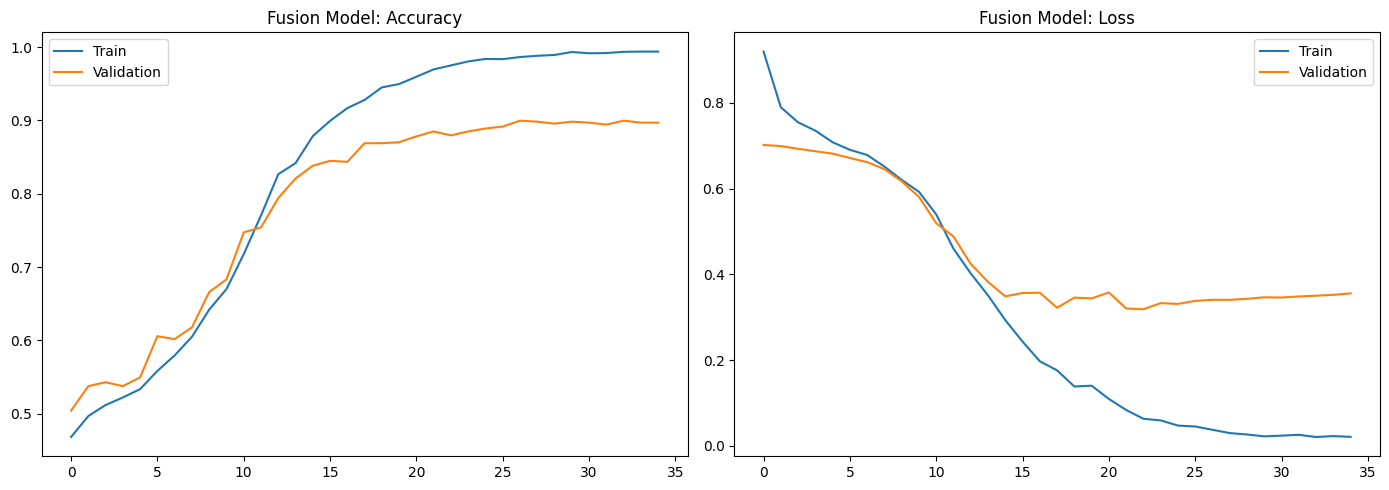

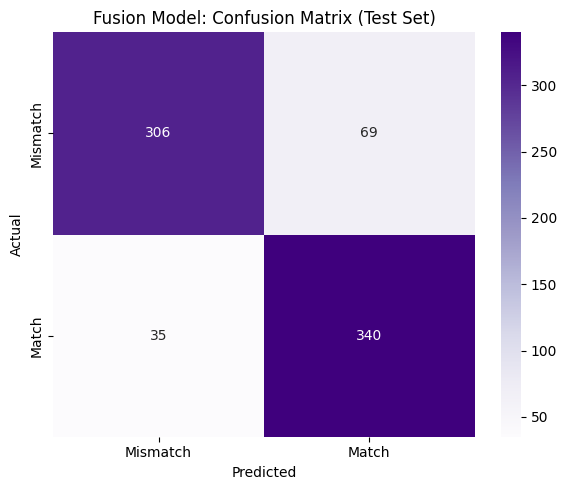

Classification Report (Test Set):
              precision    recall  f1-score   support

    Mismatch       0.90      0.82      0.85       375
       Match       0.83      0.91      0.87       375

    accuracy                           0.86       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.86      0.86      0.86       750

Precision: 0.8313 | Recall: 0.9067 | F1: 0.8673


In [ ]:

best_fusion_model = load_model(FUSION_MODEL_PATH)

# Accuracy/loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_fusion.history['accuracy'], label='Train')
axes[0].plot(history_fusion.history['val_accuracy'], label='Validation')
axes[0].set_title('Fusion Model: Accuracy'); axes[0].legend()
axes[1].plot(history_fusion.history['loss'], label='Train')
axes[1].plot(history_fusion.history['val_loss'], label='Validation')
axes[1].set_title('Fusion Model: Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

# Predict on TEST set (never touched during training/tuning)
y_pred_probs_fusion = best_fusion_model.predict(X_test_fused, verbose=0)
y_pred_fusion = (y_pred_probs_fusion >= 0.5).astype(int).flatten()

# Confusion matrix
cm_fusion = confusion_matrix(y_test_match, y_pred_fusion)
plt.figure(figsize=(6,5))
sns.heatmap(cm_fusion, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Mismatch','Match'], yticklabels=['Mismatch','Match'])
plt.title('Fusion Model: Confusion Matrix (Test Set)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

# Classification report
print("Classification Report (Test Set):")
print(classification_report(y_test_match, y_pred_fusion, target_names=['Mismatch','Match']))

precision_f = precision_score(y_test_match, y_pred_fusion)
recall_f = recall_score(y_test_match, y_pred_fusion)
f1_f = f1_score(y_test_match, y_pred_fusion)
print(f"Precision: {precision_f:.4f} | Recall: {recall_f:.4f} | F1: {f1_f:.4f}")

In [ ]:


def analyze_food_review(image_path, review_text):
    """
    Full pipeline: takes an image path and review text, runs it through
    CNN + GRU + Fusion models, and prints a clean final report.
    """
    # 1. Image: predict dish + get embedding + get class probabilities
    image_tensor = tf.io.read_file(image_path)
    image_tensor = tf.image.decode_jpeg(image_tensor, channels=3)
    image_tensor = tf.image.resize(image_tensor, [IMG_SIZE, IMG_SIZE])
    image_tensor = mobilenet_preprocess(image_tensor)
    image_tensor = tf.expand_dims(image_tensor, 0)

    dish_probs = best_cnn_model.predict(image_tensor, verbose=0)[0]
    dish_idx = np.argmax(dish_probs)
    predicted_dish = SELECTED_CLASSES[dish_idx]
    dish_confidence = dish_probs[dish_idx] * 100

    img_embedding = extract_image_embedding(image_path)

    # 2. Text: predict sentiment + get embedding + keyword vector
    sentiment_prob = best_gru_model.predict(
        texts_to_padded_sequences([clean_text(review_text)], tokenizer, MAX_SEQUENCE_LENGTH), verbose=0
    )[0][0]
    sentiment_label = "Positive" if sentiment_prob >= 0.5 else "Negative"
    sentiment_confidence = (sentiment_prob if sentiment_prob >= 0.5 else 1 - sentiment_prob) * 100

    # Approximate a 1-5 star rating from sentiment confidence (documented approximation --
    # we don't have real star-rating labels, so this maps confidence to a plausible scale)
    if sentiment_label == "Positive":
        approx_rating = 3.0 + (sentiment_prob - 0.5) * 4  # 3.0 to 5.0
    else:
        approx_rating = 3.0 - ((1 - sentiment_prob) - 0.5) * 4  # 1.0 to 3.0
    approx_rating = np.clip(approx_rating, 1.0, 5.0)

    text_embedding = extract_text_embedding(review_text)
    keyword_vector = extract_dish_keyword_vector(review_text)

    # 3. Fusion: combine everything and predict match
    fused_vector = np.concatenate([img_embedding, dish_probs, text_embedding, keyword_vector]).reshape(1, -1)
    match_prob = best_fusion_model.predict(fused_vector, verbose=0)[0][0]
    is_match = match_prob >= 0.5
    match_confidence = (match_prob if is_match else 1 - match_prob) * 100
    anomaly_detected = not is_match

    # 4. Display clean final report
    print("=" * 50)
    print("MULTI-MODAL FOOD REVIEW ANALYSIS")
    print("=" * 50)
    print(f"\nPredicted Dish: {predicted_dish}")
    print(f"Dish Confidence: {dish_confidence:.1f}%")
    print(f"\nReview: \"{review_text}\"")
    print(f"\nSentiment: {sentiment_label}")
    print(f"Sentiment Confidence: {sentiment_confidence:.1f}%")
    print(f"Predicted Rating: {approx_rating:.1f} / 5  (approximated from sentiment -- no real rating labels available)")
    print(f"\nImage-Review Match: {'YES' if is_match else 'NO'}")
    print(f"Match Confidence: {match_confidence:.1f}%")
    print(f"\nAnomaly: {'DETECTED' if anomaly_detected else 'NO'}")
    if anomaly_detected:
        mentioned_dishes = [SELECTED_CLASSES[i] for i, v in enumerate(keyword_vector) if v == 1]
        print(f"  -> Reason: image shows '{predicted_dish}' but review "
              f"{'mentions ' + ', '.join(mentioned_dishes) if mentioned_dishes else 'does not clearly mention this dish'}")
    print("=" * 50)

    return {
        'predicted_dish': predicted_dish, 'dish_confidence': dish_confidence,
        'sentiment': sentiment_label, 'sentiment_confidence': sentiment_confidence,
        'approx_rating': approx_rating, 'is_match': is_match,
        'match_confidence': match_confidence, 'anomaly_detected': anomaly_detected
    }

print("End-to-end function ready.")

End-to-end function ready.


In [ ]:
# Example 1: a genuine match
sample_match_row = multimodal_test_df[multimodal_test_df['match_label']==1].iloc[0]
print("### EXAMPLE 1: MATCHING PAIR ###")
result1 = analyze_food_review(sample_match_row['image_path'], sample_match_row['review_text'])

print("\n\n")

# Example 2: a deliberate mismatch
sample_mismatch_row = multimodal_test_df[multimodal_test_df['match_label']==0].iloc[0]
print("### EXAMPLE 2: MISMATCHED PAIR ###")
result2 = analyze_food_review(sample_mismatch_row['image_path'], sample_mismatch_row['review_text'])

### EXAMPLE 1: MATCHING PAIR ###
MULTI-MODAL FOOD REVIEW ANALYSIS

Predicted Dish: ramen
Dish Confidence: 98.9%

Review: "This ramen had excellent broth."

Sentiment: Positive
Sentiment Confidence: 88.9%
Predicted Rating: 4.6 / 5  (approximated from sentiment -- no real rating labels available)

Image-Review Match: YES
Match Confidence: 100.0%

Anomaly: NO



### EXAMPLE 2: MISMATCHED PAIR ###
MULTI-MODAL FOOD REVIEW ANALYSIS

Predicted Dish: ramen
Dish Confidence: 98.9%

Review: "The juiciness of the hamburger was acceptable."

Sentiment: Positive
Sentiment Confidence: 70.5%
Predicted Rating: 3.8 / 5  (approximated from sentiment -- no real rating labels available)

Image-Review Match: NO
Match Confidence: 100.0%

Anomaly: DETECTED
  -> Reason: image shows 'ramen' but review mentions hamburger


                         Model  Accuracy  Precision   Recall  F1-Score
Image-Only (keyword alignment)  0.902667   0.971875 0.829333  0.894964
 Text-Only (embedding+keyword)  0.504000   0.503480 0.578667  0.538462
            Multi-Modal Fusion  0.861333   0.831296 0.906667  0.867347


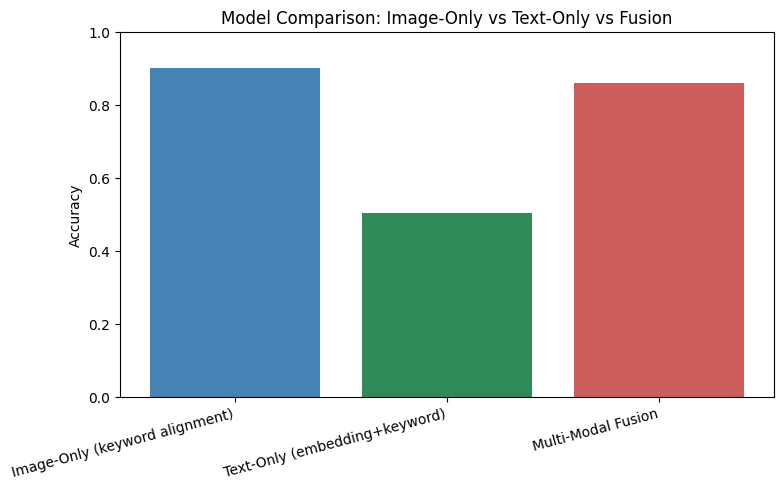

In [ ]:
from sklearn.metrics import accuracy_score
image_only_pred = (np.argmax(X_test_probs, axis=1) == np.argmax(X_test_kw, axis=1)).astype(int)
# For rows where keyword vector is all zeros (no dish mentioned), default to "no match"
no_keyword_mention = (X_test_kw.sum(axis=1) == 0)
image_only_pred[no_keyword_mention] = 0

acc_img = accuracy_score(y_test_match, image_only_pred)
prec_img = precision_score(y_test_match, image_only_pred, zero_division=0)
rec_img = recall_score(y_test_match, image_only_pred, zero_division=0)
f1_img = f1_score(y_test_match, image_only_pred, zero_division=0)

# --- Text-only baseline: train a small MLP using ONLY text embedding + keyword vector ---
text_only_input = np.concatenate([X_train_txt, X_train_kw], axis=1)
text_only_val_input = np.concatenate([X_val_txt, X_val_kw], axis=1)
text_only_test_input = np.concatenate([X_test_txt, X_test_kw], axis=1)

inputs_t = Input(shape=(text_only_input.shape[1],))
xt = BatchNormalization()(inputs_t)
xt = Dense(64, activation='relu')(xt)
xt = Dropout(0.3)(xt)
outputs_t = Dense(1, activation='sigmoid')(xt)
text_only_model = Model(inputs_t, outputs_t)
text_only_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
text_only_model.fit(text_only_input, y_train_match, validation_data=(text_only_val_input, y_val_match),
                     epochs=15, batch_size=32, verbose=0,
                     callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)])

text_only_pred = (text_only_model.predict(text_only_test_input, verbose=0) >= 0.5).astype(int).flatten()
acc_txt = accuracy_score(y_test_match, text_only_pred)
prec_txt = precision_score(y_test_match, text_only_pred)
rec_txt = recall_score(y_test_match, text_only_pred)
f1_txt = f1_score(y_test_match, text_only_pred)

# --- Full fusion (already computed) ---
acc_fusion = accuracy_score(y_test_match, y_pred_fusion)

comparison_df = pd.DataFrame({
    'Model': ['Image-Only (keyword alignment)', 'Text-Only (embedding+keyword)', 'Multi-Modal Fusion'],
    'Accuracy': [acc_img, acc_txt, acc_fusion],
    'Precision': [prec_img, prec_txt, precision_f],
    'Recall': [rec_img, rec_txt, recall_f],
    'F1-Score': [f1_img, f1_txt, f1_f]
})
print(comparison_df.to_string(index=False))

# Visual comparison
plt.figure(figsize=(8,5))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['steelblue','seagreen','indianred'])
plt.title('Model Comparison: Image-Only vs Text-Only vs Fusion')
plt.ylabel('Accuracy'); plt.ylim(0,1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()